# Final Project Part 1: Historical Automobile Sales

**Author:** SONG XINYUE  
**Student ID:** UC627465

**AI use disclosure.** OpenAI Codex was used to assist with code drafting, debugging, and presentation. I reviewed the implementation, verified the calculations, and accept responsibility for the submitted work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
DATA_URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv'
df=pd.read_csv(DATA_URL)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [2]:
print(df.shape, int(df.Year.min()), int(df.Year.max()))
print(df.isna().sum().sort_values(ascending=False).head())

(528, 15) 1980 2023
Date                   0
Year                   0
Month                  0
Recession              0
Consumer_Confidence    0
dtype: int64


## Task 1.1 Yearly automobile sales

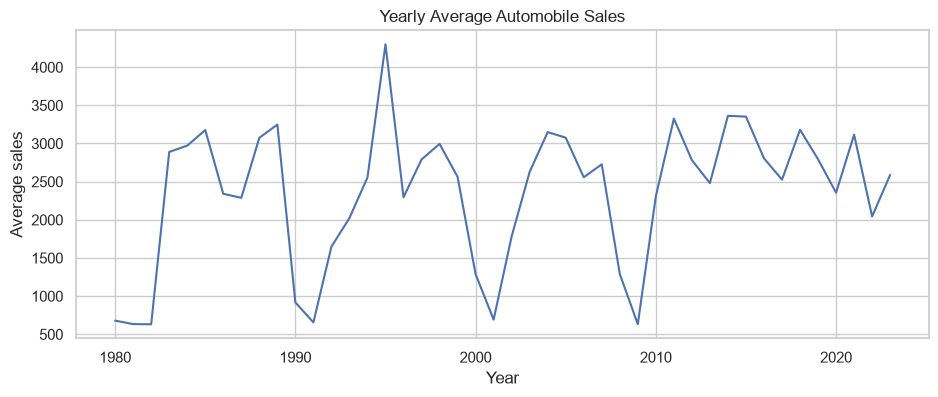

In [3]:
yr=df.groupby('Year',as_index=False)['Automobile_Sales'].mean()
yr.plot(x='Year',y='Automobile_Sales',figsize=(11,4),title='Yearly Average Automobile Sales',legend=False); plt.ylabel('Average sales'); plt.show()

## Task 1.2 Advertising expenditure and sales during non-recession periods

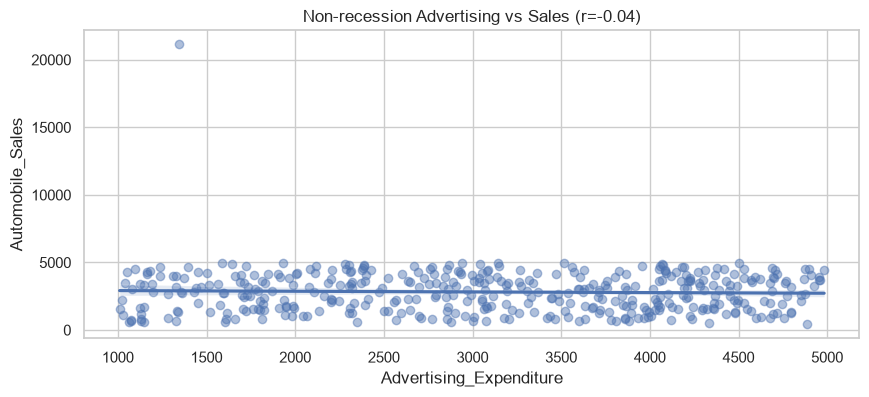

In [4]:
non=df[df.Recession==0]
r=non[['Advertising_Expenditure','Automobile_Sales']].corr().iloc[0,1]
plt.figure(figsize=(10,4)); sns.regplot(data=non,x='Advertising_Expenditure',y='Automobile_Sales',scatter_kws={'alpha':.45}); plt.title(f'Non-recession Advertising vs Sales (r={r:.2f})'); plt.show()

## Task 1.3 Vehicle-type trends in recession and non-recession periods

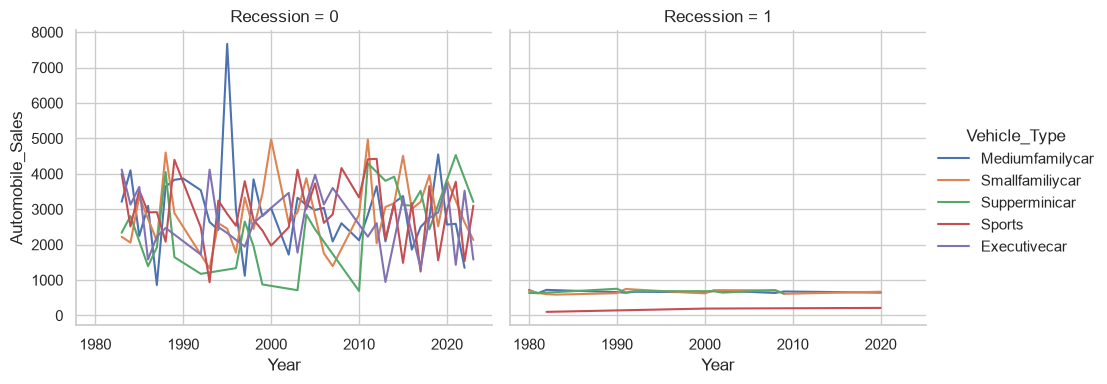

In [5]:
trend=df.groupby(['Year','Vehicle_Type','Recession'],as_index=False)['Automobile_Sales'].mean()
g=sns.relplot(data=trend,x='Year',y='Automobile_Sales',hue='Vehicle_Type',col='Recession',kind='line',height=4,aspect=1.2); g.set_titles('Recession = {col_name}'); plt.show()

## Task 1.4 GDP subplots

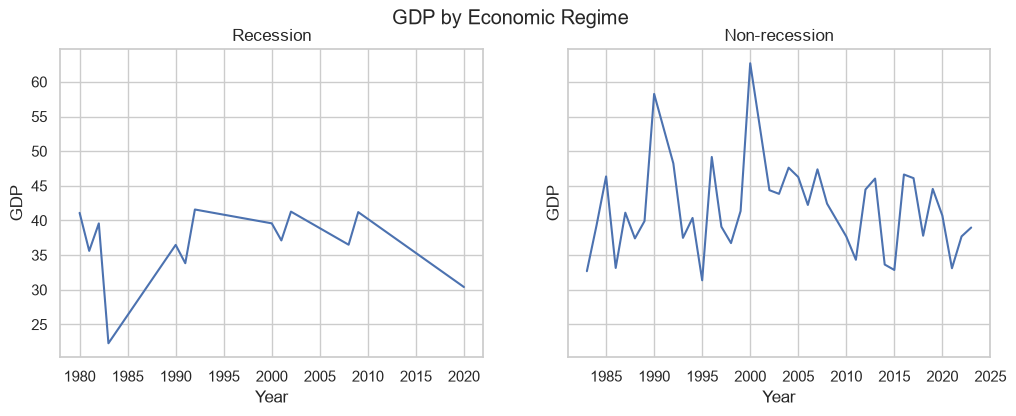

In [6]:
gdp=df.groupby(['Year','Recession'],as_index=False)['GDP'].mean()
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,flag,title in zip(axes,[1,0],['Recession','Non-recession']):
 d=gdp[gdp.Recession==flag]; ax.plot(d.Year,d.GDP); ax.set_title(title); ax.set_xlabel('Year'); ax.set_ylabel('GDP'); ax.grid(True)
fig.suptitle('GDP by Economic Regime'); plt.show()

## Task 1.5 Seasonality bubble plot

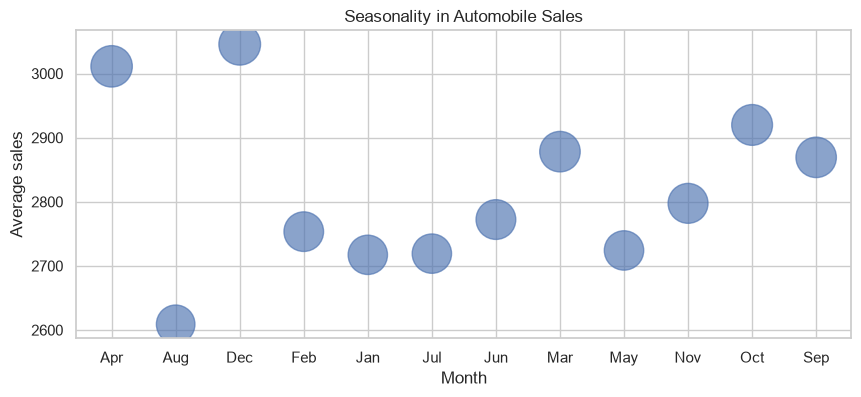

In [7]:
sea=non.groupby('Month',as_index=False)['Automobile_Sales'].mean()
plt.figure(figsize=(10,4)); plt.scatter(sea.Month,sea.Automobile_Sales,s=sea.Automobile_Sales/sea.Automobile_Sales.max()*900,alpha=.65); plt.title('Seasonality in Automobile Sales'); plt.xlabel('Month'); plt.ylabel('Average sales'); plt.show()

## Task 1.6 Price versus sales during recessions

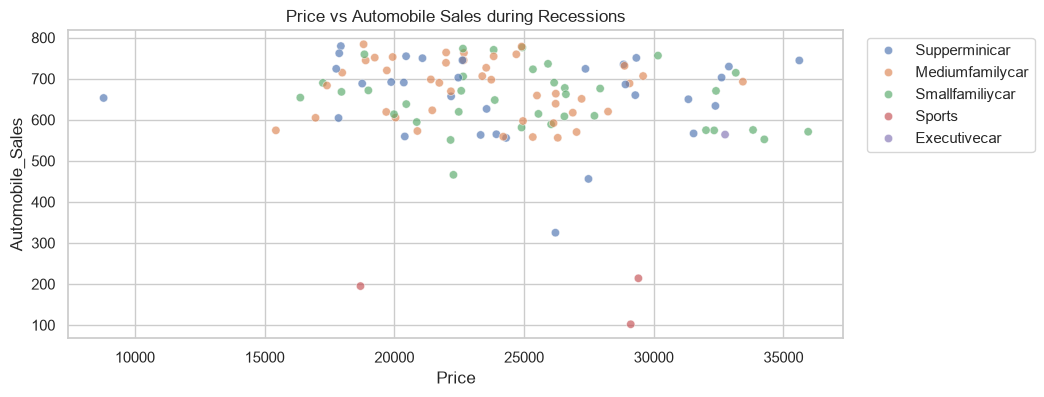

In [8]:
rec=df[df.Recession==1]
plt.figure(figsize=(10,4)); sns.scatterplot(data=rec,x='Price',y='Automobile_Sales',hue='Vehicle_Type',alpha=.65); plt.title('Price vs Automobile Sales during Recessions'); plt.legend(bbox_to_anchor=(1.02,1),loc='upper left'); plt.show()

## Task 1.7 Advertising spend: recession versus non-recession

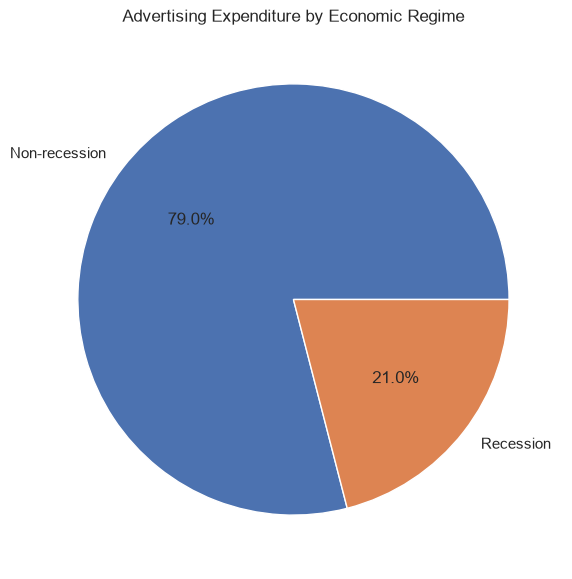

In [9]:
ad=df.groupby('Recession')['Advertising_Expenditure'].sum().rename(index={0:'Non-recession',1:'Recession'})
ad.plot.pie(autopct='%1.1f%%',figsize=(7,7),title='Advertising Expenditure by Economic Regime'); plt.ylabel(''); plt.show()

## Task 1.8 Recession advertising by vehicle type

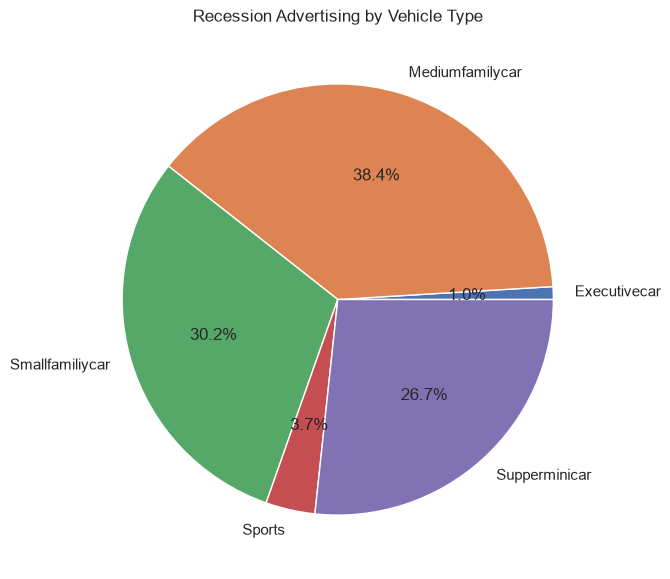

In [10]:
adtype=rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
adtype.plot.pie(autopct='%1.1f%%',figsize=(7,7),title='Recession Advertising by Vehicle Type'); plt.ylabel(''); plt.show()

## Task 1.9 Unemployment effect by vehicle type

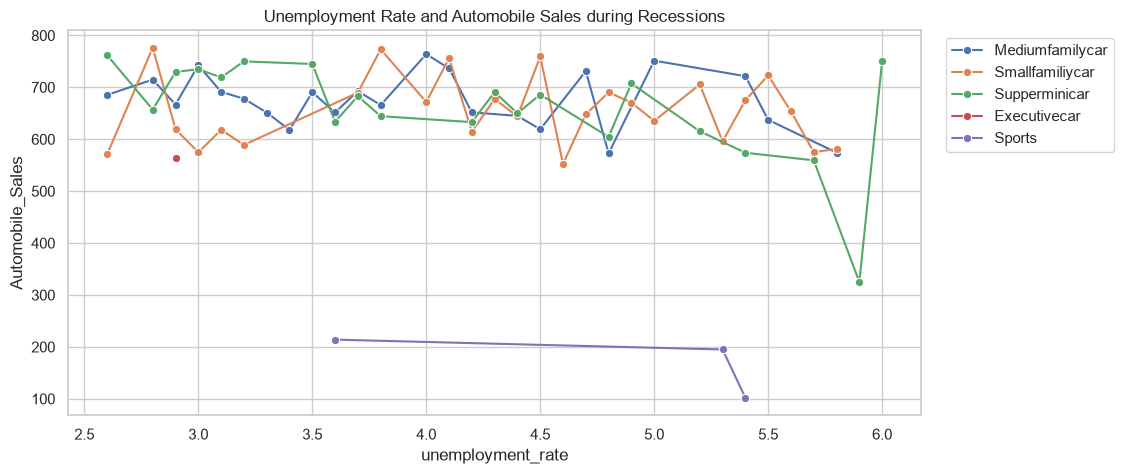

In [11]:
u=rec.groupby(['unemployment_rate','Vehicle_Type'],as_index=False)['Automobile_Sales'].mean()
plt.figure(figsize=(11,5)); sns.lineplot(data=u,x='unemployment_rate',y='Automobile_Sales',hue='Vehicle_Type',marker='o'); plt.title('Unemployment Rate and Automobile Sales during Recessions'); plt.legend(bbox_to_anchor=(1.02,1),loc='upper left'); plt.show()

## Conclusion

The visualizations show that automobile sales vary across time, economic regime, vehicle type, advertising expenditure, price, seasonality, and unemployment conditions. Part 2 provides an interactive dashboard for exploring these patterns.